# Overtake Probability Model v6 — IP07 Broad Scenario Dataset

**Data version:** `data/v6`  
**Train split:** `2022-2024`  
**Holdout test:** `2025`  
**Primary target:** `label` = `overtake_within_3`

This notebook trains a supervised classifier on the new v6 scenario dataset.

## Why v6 is different

- Positives come from the wider overtake extraction implemented in `pipeline_testing.ipynb` and ported into `pipeline/v6_pipeline.py`.
- Candidate rows are broader adjacent attacker-defender scenarios within `3.0s`, not the old `<1.0s` battle detector.
- The primary label is `within_3`, which better matches how overtakes build over multiple laps.

Because of that, the metrics here are **not directly comparable** to v1-v5 notebook scores.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data" / "v6"
TRAIN_YEARS = [2022, 2023, 2024]
TEST_YEARS = [2025]
TARGET = "label"


In [2]:
def load_years(years):
    frames = []
    for year in years:
        path = DATA_DIR / f"scenarios_{year}.csv"
        if not path.exists():
            print(f"WARNING: missing {path}")
            continue
        frame = pd.read_csv(path)
        frame["source_year"] = year
        frames.append(frame)
        print(f"{year}: {len(frame):,} rows | positive rate={frame[TARGET].mean():.2%}")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("Training data")
df_train = load_years(TRAIN_YEARS)
print()
print("Holdout data")
df_test = load_years(TEST_YEARS)

summary = pd.concat([
    df_train.assign(split="train").groupby("source_year", as_index=False)[TARGET].agg(rows="size", positive_rate="mean").rename(columns={"source_year": "year"}),
    df_test.assign(split="test").groupby("source_year", as_index=False)[TARGET].agg(rows="size", positive_rate="mean").rename(columns={"source_year": "year"}),
], ignore_index=True)
summary


Training data
2022: 11,380 rows | positive rate=11.04%
2023: 12,334 rows | positive rate=10.45%
2024: 13,229 rows | positive rate=9.27%

Holdout data


2025: 14,565 rows | positive rate=8.20%


,year,rows,positive_rate
0,2022,11380,0.110369
1,2023,12334,0.104508
2,2024,13229,0.092675
3,2025,14565,0.081977


In [3]:
# Keep the scenario framing aligned with the positive extraction by dropping pit-stop rows.
df_train = df_train[~df_train["pit_stop_involved"].astype(bool)].copy()
df_test = df_test[~df_test["pit_stop_involved"].astype(bool)].copy()

for frame in (df_train, df_test):
    bool_cols = frame.select_dtypes(include=["bool"]).columns.tolist()
    for col in bool_cols:
        frame[col] = frame[col].astype(int)

EXCLUDE = {
    TARGET,
    "overtake_next_lap",
    "overtake_within_2",
    "overtake_within_3",
    "race_name",
    "event_date",
    "attacker",
    "defender",
    "candidate_gap_threshold",
    "source_year",
}

FEATURES = [c for c in df_train.columns if c not in EXCLUDE]
CAT_COLS = [c for c in FEATURES if df_train[c].dtype == "object"]
NUM_COLS = [c for c in FEATURES if c not in CAT_COLS]

X_train = df_train[FEATURES].copy()
y_train = df_train[TARGET].astype(int)
X_test = df_test[FEATURES].copy()
y_test = df_test[TARGET].astype(int)

print(f"Train rows after pit filter: {len(X_train):,}")
print(f"Test rows after pit filter:  {len(X_test):,}")
print(f"Train positive rate: {y_train.mean():.2%}")
print(f"Test positive rate:  {y_test.mean():.2%}")
print(f"Features: {len(FEATURES)} | numeric={len(NUM_COLS)} | categorical={len(CAT_COLS)}")


Train rows after pit filter: 35,049
Test rows after pit filter:  13,883
Train positive rate: 10.76%
Test positive rate:  8.60%
Features: 98 | numeric=89 | categorical=9


In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
        ("num", "passthrough", NUM_COLS),
    ]
)

pos = int(y_train.sum())
neg = int(len(y_train) - pos)
scale_pos_weight = neg / max(pos, 1)

model = XGBClassifier(
    n_estimators=350,
    max_depth=5,
    learning_rate=0.035,
    min_child_weight=20,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.02,
    reg_lambda=1.5,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
)

pipeline = Pipeline([
    ("pre", preprocessor),
    ("model", model),
])

pipeline.fit(X_train, y_train)
test_proba = pipeline.predict_proba(X_test)[:, 1]

metrics = pd.DataFrame(
    {
        "metric": ["roc_auc", "pr_auc", "brier"],
        "value": [
            roc_auc_score(y_test, test_proba),
            average_precision_score(y_test, test_proba),
            brier_score_loss(y_test, test_proba),
        ],
    }
)
metrics


,metric,value
0,roc_auc,0.911593
1,pr_auc,0.601773
2,brier,0.099257


Best F1 threshold on 2025 PR curve: 0.718
Confusion matrix [ [TN, FP], [FN, TP] ]
[[12034   655]
 [  448   746]]


,importance
num__pace_delta_avg_3,0.086348
num__pace_delta,0.036182
num__gap_ahead,0.035562
num__strongest_sector,0.028621
num__tyre_age_difference,0.018082
cat__track_MONACO,0.017417
num__speed_fl_delta,0.015793
cat__sector_type_mixed,0.014841
cat__track_ZANDVOORT,0.014629
num__gap_mean_3,0.014417


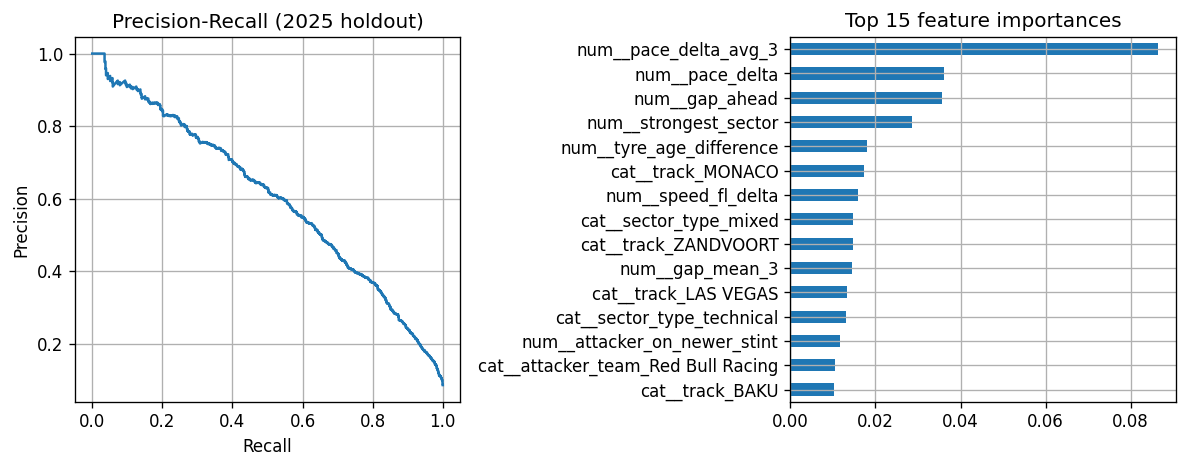

In [5]:
precision, recall, thresholds = precision_recall_curve(y_test, test_proba)
f1_scores = (2 * precision[:-1] * recall[:-1]) / np.clip(precision[:-1] + recall[:-1], 1e-9, None)
best_idx = int(np.nanargmax(f1_scores))
best_threshold = float(thresholds[best_idx])
test_pred = (test_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred)

print(f"Best F1 threshold on 2025 PR curve: {best_threshold:.3f}")
print("Confusion matrix [ [TN, FP], [FN, TP] ]")
print(cm)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(recall, precision)
ax[0].set_title("Precision-Recall (2025 holdout)")
ax[0].set_xlabel("Recall")
ax[0].set_ylabel("Precision")

feature_names = pipeline.named_steps["pre"].get_feature_names_out()
importance = pd.Series(
    pipeline.named_steps["model"].feature_importances_,
    index=feature_names,
).sort_values(ascending=False).head(15)
importance.sort_values().plot(kind="barh", ax=ax[1])
ax[1].set_title("Top 15 feature importances")
plt.tight_layout()

importance.to_frame("importance").tail(15)
